# Reflection Spectra over Frequencies for Radar Design

This notebook is 

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import os
import re

Now, the appropriate functions are defined (parsecomplexsafe, getfreq)

In [138]:
# Parse complex safe
def parse_complex_safe(s):
    """
    Parse a string from a PDF table into a complex number.
    Handles weird cases like '1.6503+', '2.34- 0.56i', etc.
    """
    if s is None:
        return complex(0, 0)
    
    s = s.strip()  # remove leading/trailing whitespace
    s = s.replace(" ", "")  # remove internal spaces
    s = s.replace('\n', '') # remove internal line breaks
    s = s.replace("i", "j")  # Python uses j for imaginary unit
    s = s.replace('–', '-') # adjusts dash type (em to en)

    # Fix cases where string ends with + or - (incomplete imaginary part)
    if re.match(r"^[+-]?[\d.]+[+-]$", s):
        s += "0j"  # add 0 as imaginary part
    
    # Fix cases where string is just a real number with trailing j
    if re.match(r"^[+-]?[\d.]+$", s):
        s += "+0j"

    try:
        c = complex(s)
    except ValueError:
        # fallback: treat as 0+0j
        c = complex(0, 0)
    return c

In [139]:
# Get frequency range
def get_frequency_range_from_pdf(material, pdf_path):
    '''
    Extracts the frequency range (min, max) for a given material
    from the PDF text.
    '''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            for line in text.split("\n"):
                if material.lower() in line.lower():
                    # Look for (X–Y GHz) after the material name
                    match = re.search(r"\((\d*\.?\d+)–(\d*\.?\d+)\s*GHz\)", line)
                    if match:
                        f_min = float(match.group(1))
                        f_max = float(match.group(2))
                        return f_min, f_max
    return None, None

Functions for gettting epsilon and mu values for 12_1, 12_4, 12_6, 12_7, 12_8 are defined

Working: 12_1, 12_6

Not yet working (error placeholder): 12_4, 12_7, 12_8

In [140]:
# 12_1
def getEpAndMu_12_1(user_f_min, user_f_max, material):
    #base_dir = os.path.dirname(__file__)  # folder where script is
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_1.pdf")

    rows = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]


    # Apply to the selected row
    real_floats = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe).apply(lambda x: x.real)
    imag_floats = df_selected.iloc[sample_idx].apply(parse_complex_safe).apply(lambda x: x.imag)

    complex_floats = real_floats + imag_floats * complex(0, 1)
    complex_floats.head()

    B = complex_floats.iloc[0]
    C = complex_floats.iloc[1]
    D = complex_floats.iloc[2]
    G = complex_floats.iloc[3]
    H = complex_floats.iloc[4]
    I = complex_floats.iloc[5]
    J = complex_floats.iloc[6]
    
    num_points = 1000  # Number of frequency points
   
    frequencies = np.linspace(user_f_min, user_f_max, num_points)
    epsilon_f = B + 2 * C * (frequencies ** D) + G * (1 - J * (frequencies - H)**2 - 1j * 2 * I * frequencies)**(-1)


    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e4)
    plt.show()

    # return values
    return(epsilon_f, mu_f)

In [141]:
# 12_4
def getEpAndMu_12_4(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

In [142]:
# 12_6
def getEpAndMu_12_6(user_f_min, user_f_max, material):
    #base_dir = os.path.dirname(__file__)  # folder where script is
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_6.pdf")

    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)
    # Convert single string into complex float
    df_selected = df[["B", "C", "D", "E", "F", "G", "H"]]

    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    E = complex(values.iloc[3])
    F = complex(values.iloc[4])
    G = complex(values.iloc[5])
    H = complex(values.iloc[6])

    #define frequency range

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + np.real(C) * (frequencies ** D) + np.imag(C) * (frequencies ** E) + F * (1 - (frequencies / G) ** 2 - 1j * 2 * frequencies / H) ** (-1))

    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e4)
    plt.show()

    # return values
    return(epsilon_f, mu_f)

In [ ]:
# 12_7 WORK TO BE DONE
def getEpAndMu_12_7(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

In [ ]:
# 12_8 WORK TO BE DONE
def getEpAndMu_12_8(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

Now, the user is asked for the material, low frequency range, and high frequency range

try 1
try 2
try 3




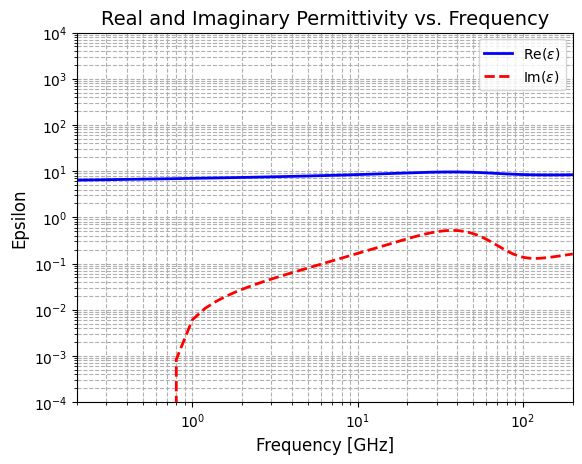

[6.3794307 -0.02085229j 6.61026166-0.01184169j 6.75983195-0.00498208j
 6.87368717+0.00084373j 6.96704922+0.00604819j 7.04699252+0.01083507j
 7.11741466+0.01532172j 7.18070396+0.01958261j 7.23843533+0.02366824j
 7.29170483+0.02761466j 7.34130748+0.03144855j 7.38783914+0.0351903j
 7.43175844+0.03885586j 7.47342626+0.04245798j 7.51313189+0.046007j
 7.55111092+0.04951146j 7.58755787+0.0529785j  7.62263526+0.05641413j
 7.65648033+0.05982349j 7.68921001+0.06321097j 7.7209248 +0.06658039j
 7.75171171+0.06993508j 7.78164654+0.07327795j 7.81079578+0.07661154j
 7.83921803+0.07993814j 7.86696523+0.08325975j 7.89408358+0.08657817j
 7.92061442+0.08989498j 7.94659481+0.09321161j 7.97205814+0.09652935j
 7.99703456+0.09984934j 8.02155141+0.10317262j 8.04563352+0.1065001j
 8.06930352+0.10983263j 8.09258209+0.11317093j 8.11548812+0.11651569j
 8.13803898+0.11986748j 8.1602506 +0.12322685j 8.18213766+0.12659426j
 8.2037137 +0.12997012j 8.22499121+0.1333548j  8.24598177+0.1367486j
 8.26669606+0.14015179j 8

In [145]:
material = input('Enter a material: ')
user_f_min = input('Enter a minimum frequency')
user_f_max = input('Enter a maximum frequency')

# Try each function

try:
    print('try 1')
    (epsilon_f, mu_f) = getEpAndMu_12_1(user_f_min, user_f_max, material)
except:
    try:
        print('try 2')
        (epsilon_f, mu_f) = getEpAndMu_12_4(user_f_min, user_f_max, material)
    except:
        try:
            print('try 3')
            (epsilon_f, mu_f) = getEpAndMu_12_6(user_f_min, user_f_max, material)
        except:
            try:
                print('try 4')
                (epsilon_f, mu_f) = getEpAndMu_12_7(user_f_min, user_f_max, material)
            except:
                try:
                    print('try 5')
                    (epsilon_f, mu_f) = getEpAndMu_12_8(user_f_min, user_f_max, material)
                except:
                    print('Material not found')
     
else:
    print("Primary function successful.")

print(epsilon_f)
print(mu_f)